# GPR MCMC
- We observed previously that it is difficult to quanitfy the uncertainteis on the fits. 
- We have the aleatoric uncertainty captured already within the model but the epistemic uncertainty in the model needs to be quantified.
- We can do this by running an MCMC.

---
- We will follow the celerite2 tutorial.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize

import celerite2
from celerite2 import terms

from prettytable import PrettyTable

import sys
from pathlib import Path

sys.path.append(str(Path('../..').resolve()))

from helpers.df_ops import prepare_df, split_df, clean_df
from helpers.priors import find_classify_signals, get_priors

def set_params(log_params, k, gp):
    # k = len(log_params) // 3
    params = np.exp(log_params)
    sigmas = params[0:k]
    rhos = params[k:2*k]
    qs = params[2*k::]
    
    gp.kernel = terms.SHOTerm(sigma=sigmas[0], rho=rhos[0], Q=qs[0])
    for k_idx in range(1,k):
        gp.kernel += terms.SHOTerm(sigma=sigmas[k_idx], rho=rhos[k_idx], Q=qs[k_idx])
    return gp

def NLL(log_params, gp, k, y):
    '''
    Calculates the NLL of a set of parameters for a local gp
    '''
    gp = set_params(log_params, k, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)

def lnPost(log_params, gp, k, y, initial_guesses, prior_std = 3):
    '''
    Calculates the log posterior.
    Returns the loglikelihood plus the logprior.
    We have defined the prior as a gaussian around the initial guesses. 
    Since the initial guesses are derived from physical reasons this is logical.
    Let the prior be fairly wide to allow for exploration.
    '''
    gp = set_params(log_params, k, gp)
    return gp.log_likelihood(y) - 0.5 * np.sum(((np.exp(log_params) - np.exp(initial_guesses)) / prior_std) ** 2)




      
       
        
        

In [6]:
datapath = r"../../Data/benchmark/HD201091_Mt_wilson_data.txt"

direct_bound_tol = 0.1
sm2016_bound_tol = 0.2
mean_bound_tol = 1

add_prefix = False
relative = True
train_split = 0.8
valid_split = 0.19

star_type = "G"
star_name = "HD201091"

error_percent = 2.5
sigma_upper_mult = 5.0
q_bounds_in = [5, 100]

verbose = True
plot = True
loop_verbose = True
loop_plot = False
loop_savefigs = False
results_verbose = True
results_plot = True
ax = None
result_plot_cadence = 1
result_plot_extra = 100

require_mid = True

n_walkers = 32

SEED = 1701

Removed 0 datapoints which had NaN.
Removed 19 datapoints that were deemed ourliers by tolerance in sind of 4 times MAD.


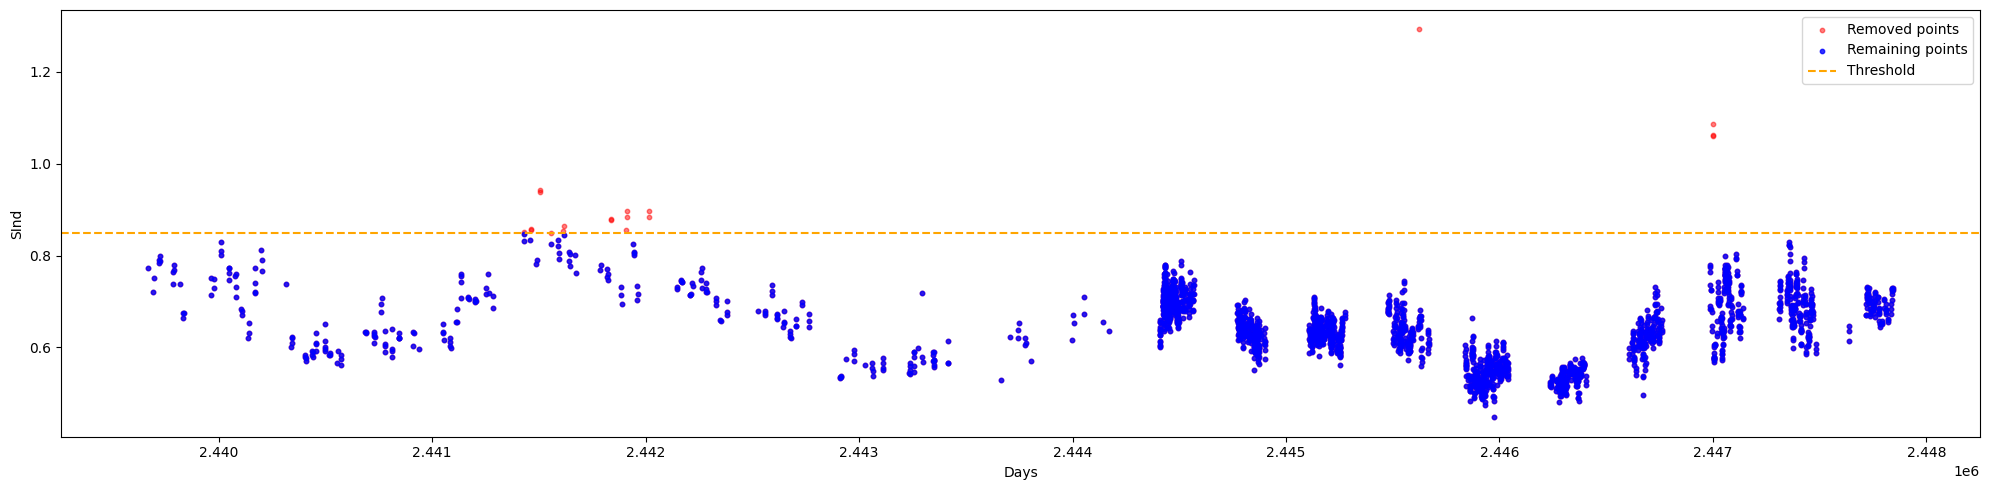

In iteration 0, period at 2730.68 days was accepted.
In iteration 1, period at 12043.36 days was accepted.
Peak at period 1366.67 days was identified to be an alias of 2730.68 days at mult 0.50 by tolerance 0.00.
In iteration 2, period at 505.26 days was accepted.
Peak at period 1377.25 days was identified to be an alias of 2730.68 days at mult 0.50 by tolerance 0.01.
In iteration 3, period at 290.64 days was accepted.
In iteration 4, period at 36.97 days was accepted.
Peak at period 2070.03 days was identified to be an alias of 505.26 days at mult 4.00 by tolerance 0.02.
In iteration 5, period at 443.94 days was accepted.
Peak at period 36.60 days was identified to be an alias of 36.97 days at mult 1.00 by tolerance 0.01.
In iteration 6, period at 39.89 days was accepted.
In iteration 7, period at 33.32 days was accepted.
Peak at period 156.32 days was identified to be an alias of 39.89 days at mult 4.00 by tolerance 0.02.
Peak at period 252.68 days was identified to be an alias of 50

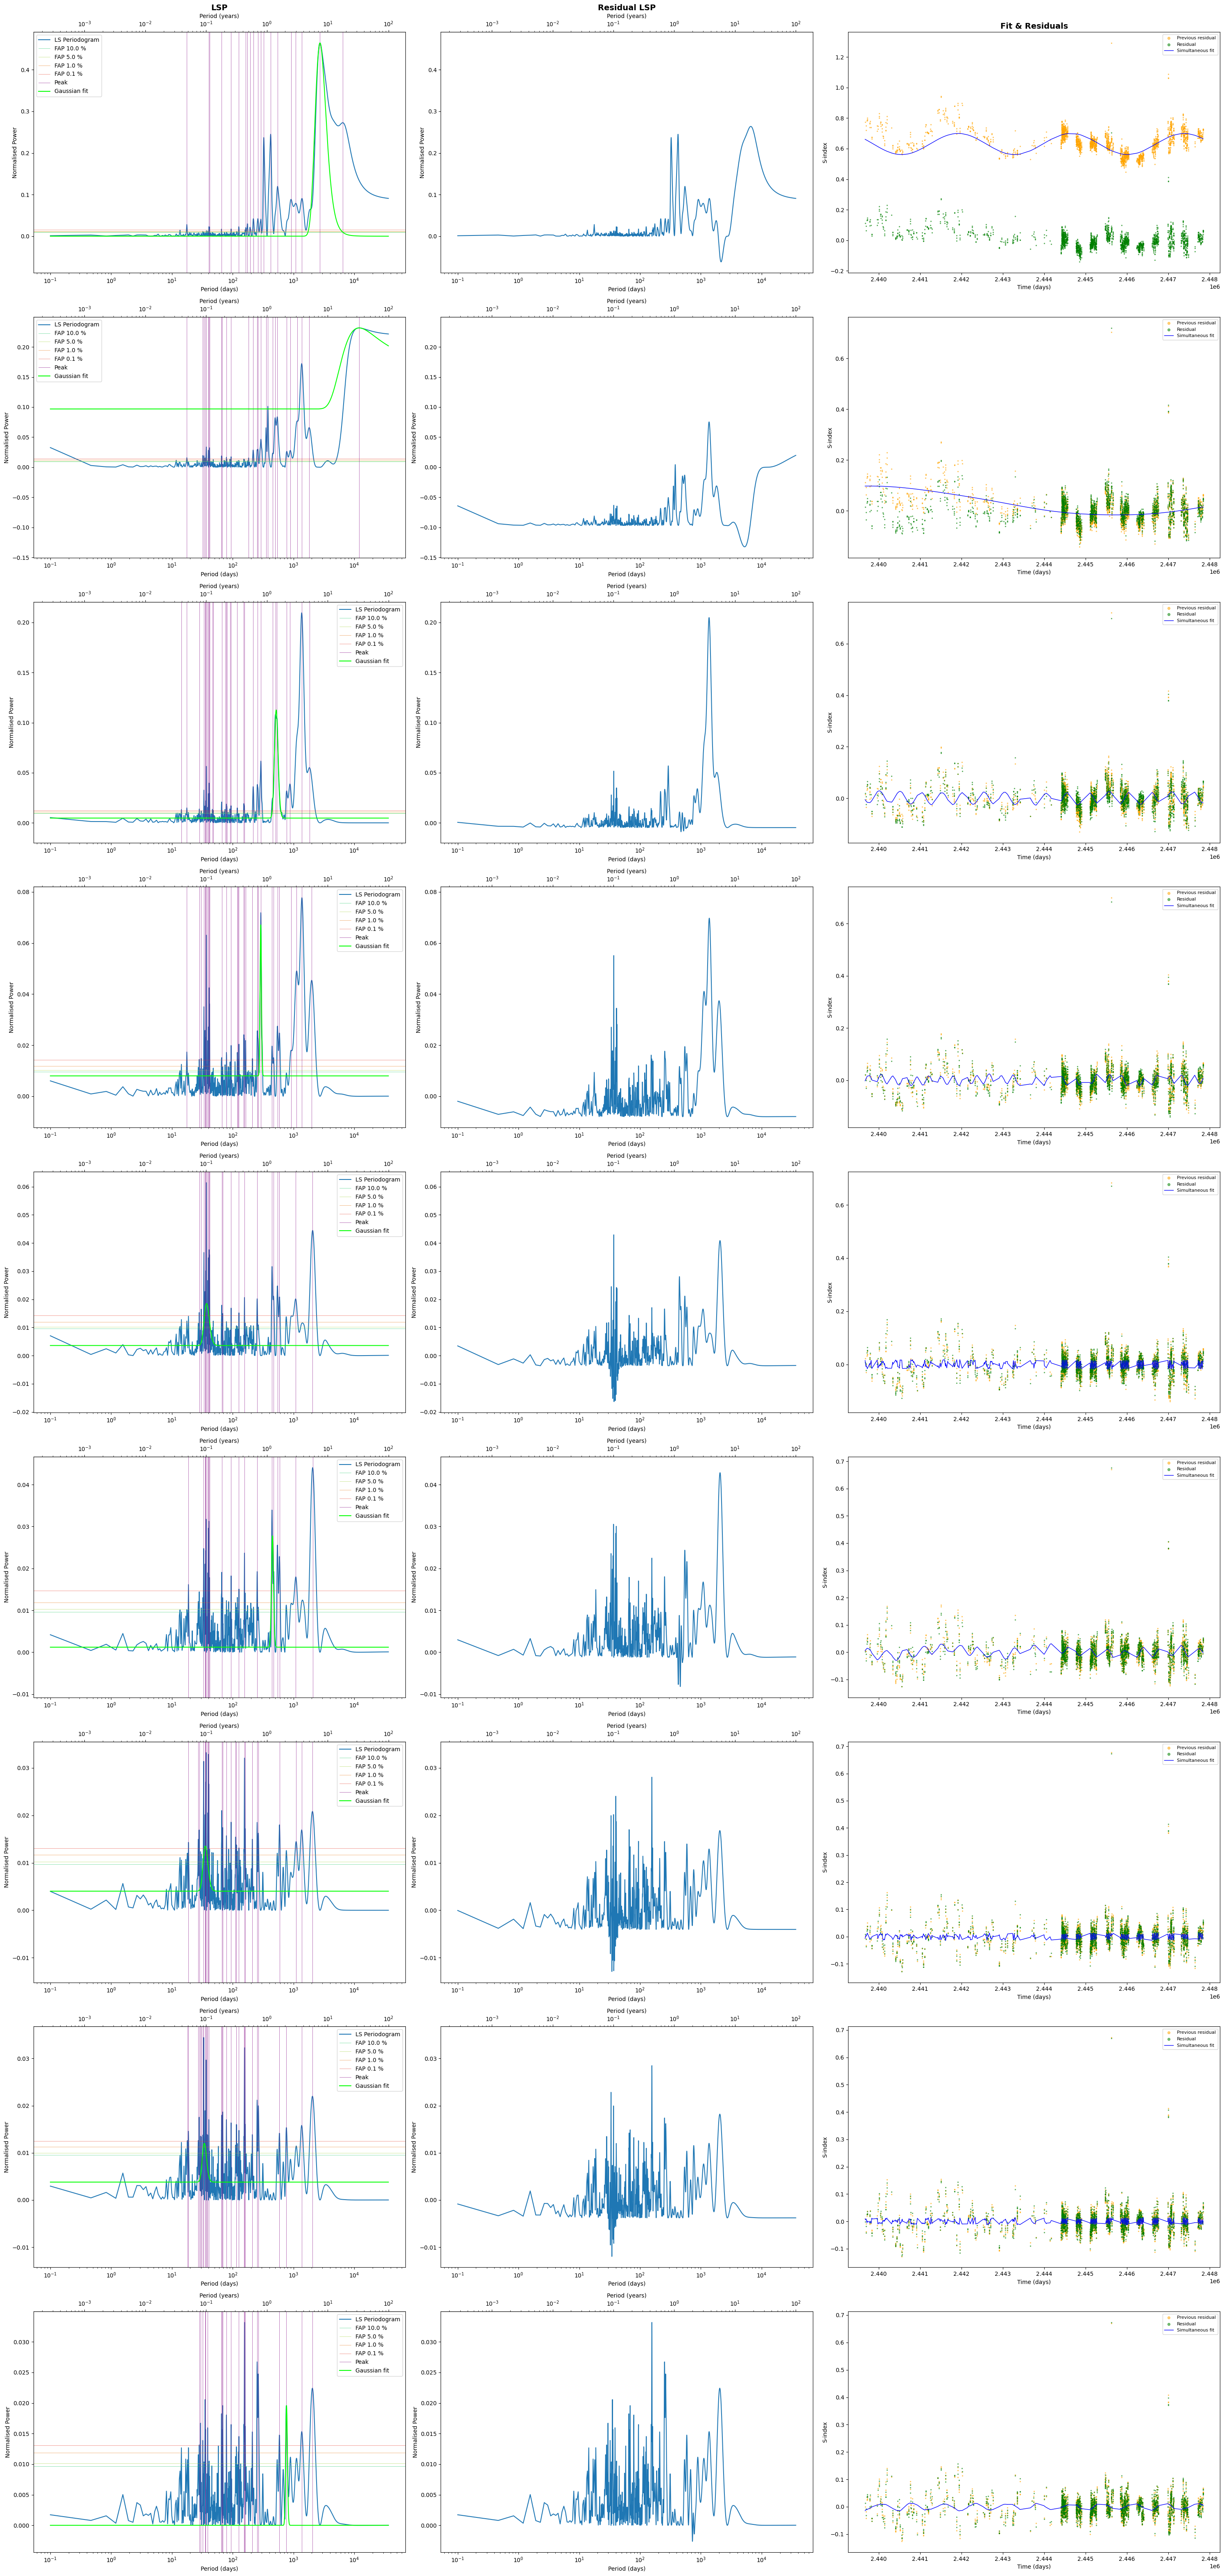

Accepted periods and their heights
+----------+-------+--------+--------------+
|   Days   | Years | Height |     SNR      |
+----------+-------+--------+--------------+
| 2730.68  |  7.48 | 0.4644 |   23570.79   |
| 12043.36 | 33.00 | 0.2316 | 117241745.13 |
|  505.26  |  1.38 | 0.1082 |    18.65     |
|  290.64  |  0.80 | 0.0718 |    10.01     |
|  36.97   |  0.10 | 0.0614 |     9.87     |
|  443.94  |  1.22 | 0.0339 |     7.53     |
|  39.89   |  0.11 | 0.0329 |     6.19     |
|  33.32   |  0.09 | 0.0345 |     7.37     |
|  762.59  |  2.09 | 0.0196 |    13.95     |
+----------+-------+--------+--------------+


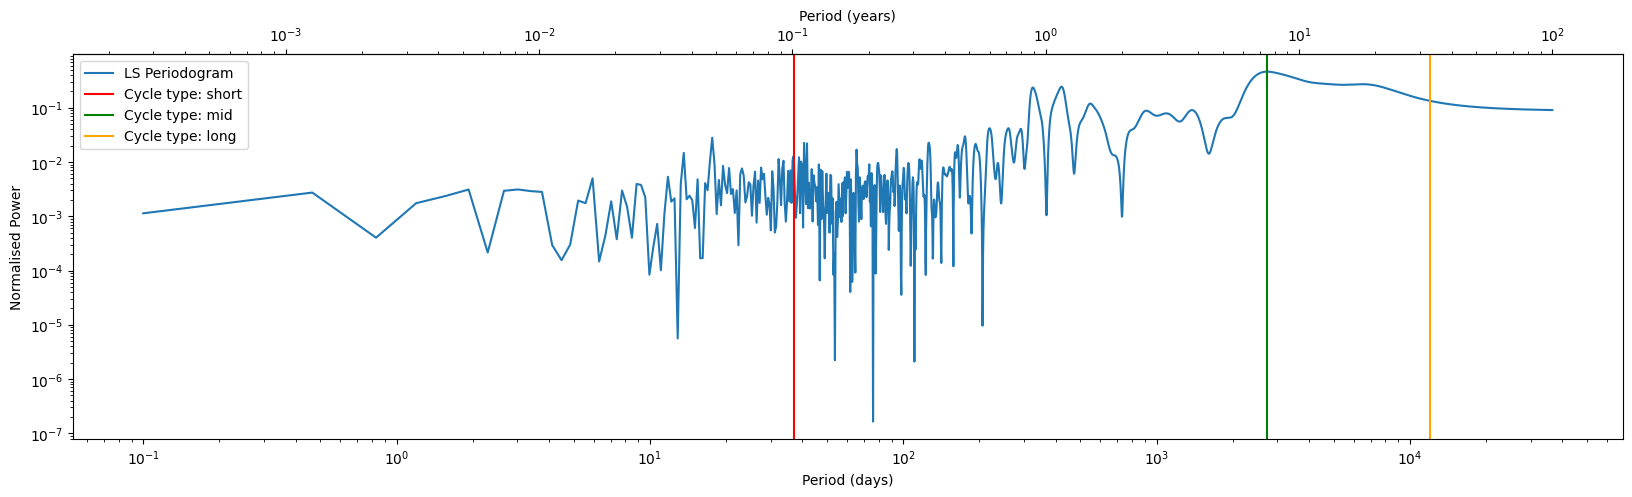

Classified Signals
+------------+------------+-------------+
| Cycle Type | Prior Days | Prior Years |
+------------+------------+-------------+
|   Short    |   36.97    |     0.10    |
|    Mid     |  2730.68   |     7.48    |
|    Long    |  12043.36  |    33.00    |
+------------+------------+-------------+
+------------+------------+-------------+------------------------------------------------------------------+----------------+--------+
| Cycle Type | Prior Days | Prior Years |                           Bounds Days                            |  Bounds Years  | Source |
+------------+------------+-------------+------------------------------------------------------------------+----------------+--------+
|   Short    |   36.97    |     0.10    | [np.float64(33.26874088740888), np.float64(40.661794417944186)]  |  (0.09, 0.11)  | found  |
|    Mid     |  2730.68   |     7.48    | [np.float64(2457.6163423634234), np.float64(3003.7533073330733)] |  (6.73, 8.23)  | found  |
|    Long   

In [4]:
# Read the data into a "raw" df
raw_df = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)

# Prep the df adds the column names etc
data_df = prepare_df(raw_df, add_prefix=add_prefix, relative=relative)

# Split the data
dirty_train_df, dirty_valid_df, test_df = split_df(data_df,
                                                train_split=train_split, valid_split=valid_split)

# Clean the dataset for outliers
train_df, valid_df, _ = clean_df(dirty_train_df, dirty_valid_df, tol=4,
                        verbose=verbose, plot=plot)

# Classify signal data and get priors
classified_signal_data = find_classify_signals(dirty_train_df,
                                        plot_fitpeaks=plot, verbose_fitpeaks=verbose,
                                        plot_genpriors=plot, verbose_genpriors=verbose)

rho_priors, rho_prior_bounds, rho_sources = get_priors(classified_signal_data,
                                                                star_type=star_type,
                                                                direct_bound_tol = direct_bound_tol, 
                                                                sm2016_bound_tol = sm2016_bound_tol, 
                                                                mean_bound_tol = mean_bound_tol,
                                                                verbose=verbose)


In [ ]:
#-----Do the model training and comparison---------
train_yerr = train_df['sind'] * error_percent / 100

train_mean = train_df['sind'].mean()
train_std  = train_df['sind'].std()

# Define the prior combos to try (k, [[q_priors], [rho_priors]])
prior_combos = {
        "1s":    {'k': 1, 'q_priors': None,          'cycle_keys': ['short']},
        "1m":    {'k': 1, 'q_priors': None,          'cycle_keys': ['mid']},
        "1l":    {'k': 1, 'q_priors': None,          'cycle_keys': ['long']},

        "2sm":   {'k': 2, 'q_priors': None,          'cycle_keys': ['short', 'mid']},
        "2ml":   {'k': 2, 'q_priors': None,          'cycle_keys': ['mid',   'long']},
        "2sl":   {'k': 2, 'q_priors': None,          'cycle_keys': ['short', 'long']},

        "3sml":  {'k': 3, 'q_priors': None,          'cycle_keys': ['short', 'mid', 'long']},

        "const": {'k': 1, 'q_priors': "overdamped",  'cycle_keys': ['mid']},
}

if require_mid:
        prior_combos = {key: val for key, val in prior_combos.items() if 'mid' in val['cycle_keys']}

# Set up the loop
best_combo  = None
best_NLPD   = np.inf
best_gp     = None
best_params = None
best_initial_guess = None

# Run the loop
for combo_name, combo_info in prior_combos.items():
        k = combo_info['k']
        q_prior_type = combo_info['q_priors']
        cycle_keys = combo_info['cycle_keys']
        
        np.random.seed(SEED)

        #---- q priors----
        if q_prior_type == 'overdamped':
                q_0s     = [np.random.uniform(0, 0.5) for _ in range(k)]
        else:
                q_0s     = [np.random.uniform(0.5, 1) for _ in range(k)]

        #---remaining priors----
        sigma_0s = [train_std / k for _ in range(k)]
        rho_0s = [rho_priors[cycle_key] for cycle_key in cycle_keys]

        initial_guess = np.concatenate([
                np.log(sigma_0s),
                np.log(rho_0s),
                np.log(q_0s)
        ])

        #----q bounds-----
        if q_prior_type == 'overdamped':
                q_bounds     = [(-np.inf, np.log(0.5)) for _ in range(k)]
        else:
                q_bounds     = [(np.log(q_bounds_in[0]), np.log(q_bounds_in[1])) for _ in range(k)]

        sigma_upper  = train_std * sigma_upper_mult
        sigma_bounds = [(np.log(1e-4), np.log(sigma_upper)) for _ in range(k)]
        rho_bounds   = np.log([rho_prior_bounds[cycle_key] for cycle_key in cycle_keys])

        bounds = np.concatenate([sigma_bounds, rho_bounds, q_bounds])

        # Create the initial kernel for this iteration
        kernel = terms.SHOTerm(sigma=sigma_0s[0], rho=rho_0s[0], Q=q_0s[0])
        for k_idx in range(1, k):
                kernel += terms.SHOTerm(sigma=sigma_0s[k_idx], rho=rho_0s[k_idx], Q=q_0s[k_idx])

        # Define and compute the GP
        gp = celerite2.GaussianProcess(kernel, mean=train_mean)
        gp.compute(train_df['day'], yerr=train_yerr)

        # Train the GP
        gp_results = minimize(
                NLL, initial_guess,
                args=(gp, k, train_df['sind'].to_numpy()),
                method='L-BFGS-B',
                bounds=bounds
                )

        gp   = set_params(gp_results.x, k, gp)
        gp.recompute()
        best = np.exp(gp_results.x)

        if loop_verbose:
                table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
                best_sigmas = best[0:k]
                best_rhos   = best[k:2*k]
                best_qs     = best[2*k:]
                for k_idx in range(k):
                        table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",
                                        f"{best_rhos[k_idx]:.2f}", f"{best_rhos[k_idx]/365:.2f}"])
                print(gp_results.success, gp_results.message)
                print(f"For k = {k}")
                print(table)

        # Predict on validation set
        mu, cov = gp.predict(train_df['sind'], t=valid_df['day'], return_var=True)
        std = np.sqrt(cov)

        # Model comparison via NLPD
        y_valid    = valid_df['sind'].to_numpy()
        valid_yerr = valid_df['sind'] * error_percent / 100
        total_var  = cov + valid_yerr**2
        nlpd_per_point = 0.5 * np.log(2 * np.pi * total_var) + (y_valid - mu)**2 / (2 * total_var)
        mean_nlpd = nlpd_per_point.mean()

        if mean_nlpd < best_NLPD:
                best_combo  = combo_name
                best_NLPD   = mean_nlpd
                best_gp     = gp
                best_params = best
                best_initial_guess = initial_guess 

        if loop_plot:
                loop_fig, loop_ax = plt.subplots(figsize=(20, 5))
                loop_ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
                loop_ax.plot(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5)
                
                loop_ax.set_title(star_name + " " + combo_name)

                loop_ax.plot(valid_df['year'], mu, color='green', label='Predictions')
                loop_ax.fill_between(valid_df['year'], mu - std, mu + std,
                                        color='green', alpha=0.2, label='Uncertainties')
                
                loop_ax.legend()

                loop_ax.text(0.02, 0.05, f"NLPD = {mean_nlpd:.4f}",
                        transform=loop_ax.transAxes, fontsize=10, verticalalignment='bottom',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
                
                if loop_savefigs:
                        loop_fig.savefig(f"./figs/gpr_{star_name}_{int(round(train_split * 100)):02d}_{combo_name}.png", dpi=100, bbox_inches='tight')
                        plt.close(loop_fig)

                else:
                        plt.show()

        if loop_verbose:
                print(f"Mean NLPD on validation set ({combo_name}): {mean_nlpd:.4f}")


True CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
For k = 1
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.3572 | 5.00 |  2457.62   |     6.73    |
+--------+------+------------+-------------+
Mean NLPD on validation set (1m): -0.2278
True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
For k = 2
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.0600 | 5.00 |   33.27    |     0.09    |
| 0.1083 | 5.00 |  2457.62   |     6.73    |
+--------+------+------------+-------------+
Mean NLPD on validation set (2sm): -1.1781
True CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
For k = 2
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.3572 | 5.00 |  2457.62   |     6.73    |
| 0.3572 | 5.00 |  10839.03  |    29.70    |

In [ ]:
import emcee
#-------Now we have the best model------

# Perform MCMC on best model to find the undertainty in the model
np.random.seed(SEED)
# Samples in param space
walker_start_coords = np.log(best_params) + 1e-5 * np.random.randn(n_walkers, len(best_params)) # Sample in log space

k = prior_combos[best_combo]['k']
y = train_df['sind'].to_numpy()

sampler = emcee.EnsembleSampler(walker_start_coords.shape[0], # number of samplers
                                                        walker_start_coords.shape[1], # number of params
                                                        lnPost, # telling it to sample from this posterior
                                                        args=(best_gp, k, y, best_initial_guess)
                                                        )

sampler.run_mcmc(walker_start_coords, nsteps=2000, progress=True)




emcee: Exception while calling your likelihood function:
  params: [-2.80730634 -2.35308839 -3.66764125  3.50461322  7.80693637  9.29089325
  1.60943082  1.6094422   1.62433092]
  args: (<celerite2.numpy.GaussianProcess object at 0x000002729D375DE0>, 3, array([0.7735, 0.721 , 0.7504, ..., 0.7039, 0.7258, 0.7291], shape=(2336,)), array([-2.63902212,  7.91230771, -3.1074101 ]))
  kwargs: {}
  exception:


Traceback (most recent call last):
  File "c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "C:\Users\Joey\AppData\Local\Temp\ipykernel_15516\4007058865.py", line 49, in lnPost
    return gp.log_likelihood(y) - 0.5 * np.sum(((np.exp(log_params) - np.exp(initial_guesses)) / prior_std) ** 2)
ValueError: operands could not be broadcast together with shapes (9,) (3,) 


ValueError: operands could not be broadcast together with shapes (9,) (3,) 

In [ ]:

# Predict on a dense regular grid for smooth plotting
t_start = valid_df['day'].iloc[0]
t_end   = valid_df['day'].iloc[-1] + result_plot_extra
sampled_days = np.arange(t_start, t_end, result_plot_cadence)

mu, cov = best_gp.predict(train_df['sind'], t=sampled_days, return_var=True)
std = np.sqrt(cov)
results = pd.DataFrame({
        'forecast': mu,
        'lower':    mu - std,
        'upper':    mu + std,
}, index=sampled_days)

# Convert sampled days to years for plotting
day_ref       = train_df['day'].iloc[0]
year_ref      = train_df['year'].iloc[0]
sampled_years = year_ref + (sampled_days - day_ref) / 365.25

if results_verbose: # Print best model params
        print(f"The best params were found for {best_combo} with NLPD of {best_NLPD}.")
        k = prior_combos[best_combo]['k']
        table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
        best_sigmas = best_params[0:k]
        best_rhos   = best_params[k:2*k]
        best_qs     = best_params[2*k:]
        for k_idx in range(k):
                table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",
                                f"{best_rhos[k_idx]:.2f}", f"{best_rhos[k_idx]/365:.2f}"])
        print(table)

if results_plot: # Plot best model predictions
        if ax is None: # Enables passthrough
                fig, ax = plt.subplots(figsize=(20, 5))
        ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
        ax.scatter(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5, marker = 'x')
        

        ax.set_title(f"Best model for {star_name} is {best_combo}")
        ax.plot(sampled_years, results['forecast'], color='green', label='Predictions')
        ax.fill_between(sampled_years, results['lower'], results['upper'],
                        color='green', alpha=0.2, label='Uncertainties')
        ax.legend()
        ax.text(0.02, 0.05, f"NLPD = {best_NLPD:.4f}",
                transform=ax.transAxes, fontsize=10, verticalalignment='bottom',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
